# Fine-tune YOLOv11 on Sports Image Dataset

Dataset: Sports_100_image_dataset

## 1. Importing Libraries

In [1]:
import os
import math
import glob
import shutil
from pathlib import Path

import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"

print("torch :", torch.__version__)
print("device:", device)

torch : 2.10.0+cu128
device: cpu


## 2. Dataset Path and Parameters

In [2]:
DATASET = "/home/ayush-ubantu/Downloads/Jamia/Lab/Sem3/LabE/Sports_100_image_dataset"

train_dir = os.path.join(DATASET, "train")
valid_dir = os.path.join(DATASET, "valid")
test_dir  = os.path.join(DATASET, "test")

MODEL_NAME       = "yolo11n-cls.pt"
EPOCHS           = 10
IMG_SIZE         = 224
BATCH            = 8

USE_SUBSET       = True
N_CLASSES        = 10
IMAGES_PER_CLASS = 40

NUM_TEST_IMAGES  = 100
SHOW_IMAGES      = 12

print("Dataset :", DATASET)
print("Exists  :", os.path.exists(DATASET))

Dataset : /home/ayush-ubantu/Downloads/Jamia/Lab/Sem3/LabE/Sports_100_image_dataset
Exists  : True


## 3. Loading and Checking the Dataset

In [3]:
classes = sorted([d for d in os.listdir(train_dir)
                  if os.path.isdir(os.path.join(train_dir, d))])

print("Total classes:", len(classes))
print("First 10     :", classes[:10])
print()

for name, path in [("train", train_dir), ("valid", valid_dir), ("test", test_dir)]:
    total = 0
    for c in classes:
        folder = os.path.join(path, c)
        if os.path.isdir(folder):
            total = total + len(os.listdir(folder))
    print(f"{name:6s}:", total, "images")

Total classes: 100
First 10     : ['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling']

train : 13493 images
valid : 500 images
test  : 500 images


## 4. Reading sports.csv

In [4]:
csv_file = os.path.join(DATASET, "sports.csv")
data_csv = pd.read_csv(csv_file)

print("Shape  :", data_csv.shape)
print("Columns:", list(data_csv.columns))
print()
data_csv.head()

Shape  : (14493, 4)
Columns: ['class id', 'filepaths', 'labels', 'data set']



,class id,filepaths,labels,data set
0,0,train/air hockey/001.jpg,air hockey,train
1,0,train/air hockey/002.jpg,air hockey,train
2,0,train/air hockey/003.jpg,air hockey,train
3,0,train/air hockey/004.jpg,air hockey,train
4,0,train/air hockey/005.jpg,air hockey,train


## 5. Creating a Small Subset

In [5]:
if USE_SUBSET:
    small_dir = "sports_small"
    selected = classes[:N_CLASSES]

    if os.path.exists(small_dir):
        shutil.rmtree(small_dir)

    for split in ["train", "valid"]:
        for c in selected:
            src = os.path.join(DATASET, split, c)
            dst = os.path.join(small_dir, split, c)
            os.makedirs(dst, exist_ok=True)

            images = sorted(os.listdir(src))[:IMAGES_PER_CLASS]
            for img in images:
                shutil.copy(os.path.join(src, img), os.path.join(dst, img))

    data_dir = small_dir
    used_classes = selected
else:
    data_dir = DATASET
    used_classes = classes

print("Training folder:", data_dir)
print("Classes used   :", len(used_classes))

for split in ["train", "valid"]:
    n = 0
    for c in used_classes:
        p = os.path.join(data_dir, split, c)
        if os.path.isdir(p):
            n = n + len(os.listdir(p))
    print(f"{split:6s}:", n, "images")

Training folder: sports_small
Classes used   : 10
train : 400 images
valid : 50 images


## 6. Loading the Pre-trained Model

In [6]:
model = YOLO(MODEL_NAME)

print("Model         :", MODEL_NAME)
print("Task          :", model.task)
print("Pretrained on :", len(model.names), "classes")
print()
print("Final layer before fine-tuning:")
print(model.model.model[-1])

Model         : yolo11n-cls.pt
Task          : classify
Pretrained on : 1000 classes

Final layer before fine-tuning:
Classify(
  (conv): Conv(
    (conv): Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.0, inplace=True)
  (linear): Linear(in_features=1280, out_features=1000, bias=True)
)


## 7. Fine-tuning the Model

In [7]:
results = model.train(
    data=data_dir,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    workers=2,
    name="sports_cls",
    exist_ok=True,
    seed=42,
)

SAVE_DIR = Path(results.save_dir)
BEST_MODEL = SAVE_DIR / "weights" / "best.pt"

print()
print("Run folder  :", SAVE_DIR)
print("Best weights:", BEST_MODEL)

New https://pypi.org/project/ultralytics/8.4.163 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.138 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (13th Gen Intel Core i3-1315U)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sports_small, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

## 8. Validating the Model

In [8]:
best = YOLO(str(BEST_MODEL))

metrics = best.val(data=data_dir, imgsz=IMG_SIZE, device=device)

print("Top-1 accuracy:", round(float(metrics.top1) * 100, 2), "%")
print("Top-5 accuracy:", round(float(metrics.top5) * 100, 2), "%")

Ultralytics 8.4.138 🚀 Python-3.12.3 torch-2.10.0+cu128 CPU (13th Gen Intel Core i3-1315U)
YOLO11n-cls summary (fused): 47 layers, 1,538,834 parameters, 0 gradients, 3.2 GFLOPs
train: /home/ayush-ubantu/Downloads/Jamia/Lab/Sem3/LabE/sports_small/train... found 400 images in 10 classes ✅ 
val: /home/ayush-ubantu/Downloads/Jamia/Lab/Sem3/LabE/sports_small/valid... found 50 images in 10 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 928.2±324.1 MB/s, size: 26.7 KB)
val: Scanning /home/ayush-ubantu/Downloads/Jamia/Lab/Sem3/LabE/sports_small/valid... 50 images, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 13.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 4/4 4.9it/s 0.8s0.4s
                   all       0.96          1
Speed: 0.0ms preprocess, 7.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /home/ayush-ubantu/Downloads/Jamia/Lab/Sem3/LabE/runs/classify/val-3
Top-1 accuracy: 96.0 %
Top-5 accuracy: 100.0 %


## 9. Predicting on Test Images

In [9]:
test_images = sorted(glob.glob(os.path.join(test_dir, "*", "*.jpg")))[:NUM_TEST_IMAGES]
print("Test images:", len(test_images))

preds = best.predict(source=test_images, imgsz=IMG_SIZE, device=device, verbose=False)

rows = []
for r in preds:
    path = r.path
    class_id = r.probs.top1
    conf = float(r.probs.top1conf)

    rows.append({
        "image":        os.path.basename(path),
        "actual":       os.path.basename(os.path.dirname(path)),
        "predicted":    r.names[class_id],
        "confidence_%": round(conf * 100, 2),
    })

df = pd.DataFrame(rows)
df["correct"] = df["actual"] == df["predicted"]
df.index = df.index + 1

print()
print("=" * 70)
print("PREDICTIONS ON TEST IMAGES")
print("=" * 70)
print(df.to_string())
print()
print("Total images :", len(df))
print("Correct      :", df["correct"].sum())
print("Accuracy     :", round(df["correct"].mean() * 100, 2), "%")
print("Avg confidence:", round(df["confidence_%"].mean(), 2), "%")
df

Test images: 100

PREDICTIONS ON TEST IMAGES
     image           actual        predicted  confidence_%  correct
1    1.jpg       air hockey       air hockey        100.00     True
2    2.jpg       air hockey       air hockey         99.99     True
3    3.jpg       air hockey       air hockey         99.68     True
4    4.jpg       air hockey       air hockey        100.00     True
5    5.jpg       air hockey       air hockey         99.96     True
6    1.jpg  ampute football  ampute football         99.64     True
7    2.jpg  ampute football  ampute football         99.95     True
8    3.jpg  ampute football  ampute football         78.76     True
9    4.jpg  ampute football  ampute football         99.86     True
10   5.jpg  ampute football  ampute football         99.75     True
11   1.jpg          archery          archery        100.00     True
12   2.jpg          archery          archery         99.95     True
13   3.jpg          archery          archery         99.26     True
14 

,image,actual,predicted,confidence_%,correct
1,1.jpg,air hockey,air hockey,100.00,True
2,2.jpg,air hockey,air hockey,99.99,True
3,3.jpg,air hockey,air hockey,99.68,True
4,4.jpg,air hockey,air hockey,100.00,True
5,5.jpg,air hockey,air hockey,99.96,True
...,...,...,...,...,...
96,1.jpg,cheerleading,basketball,66.75,False
97,2.jpg,cheerleading,baseball,69.25,False
98,3.jpg,cheerleading,basketball,69.37,False
99,4.jpg,cheerleading,basketball,95.99,False


## 10. Displaying Predictions

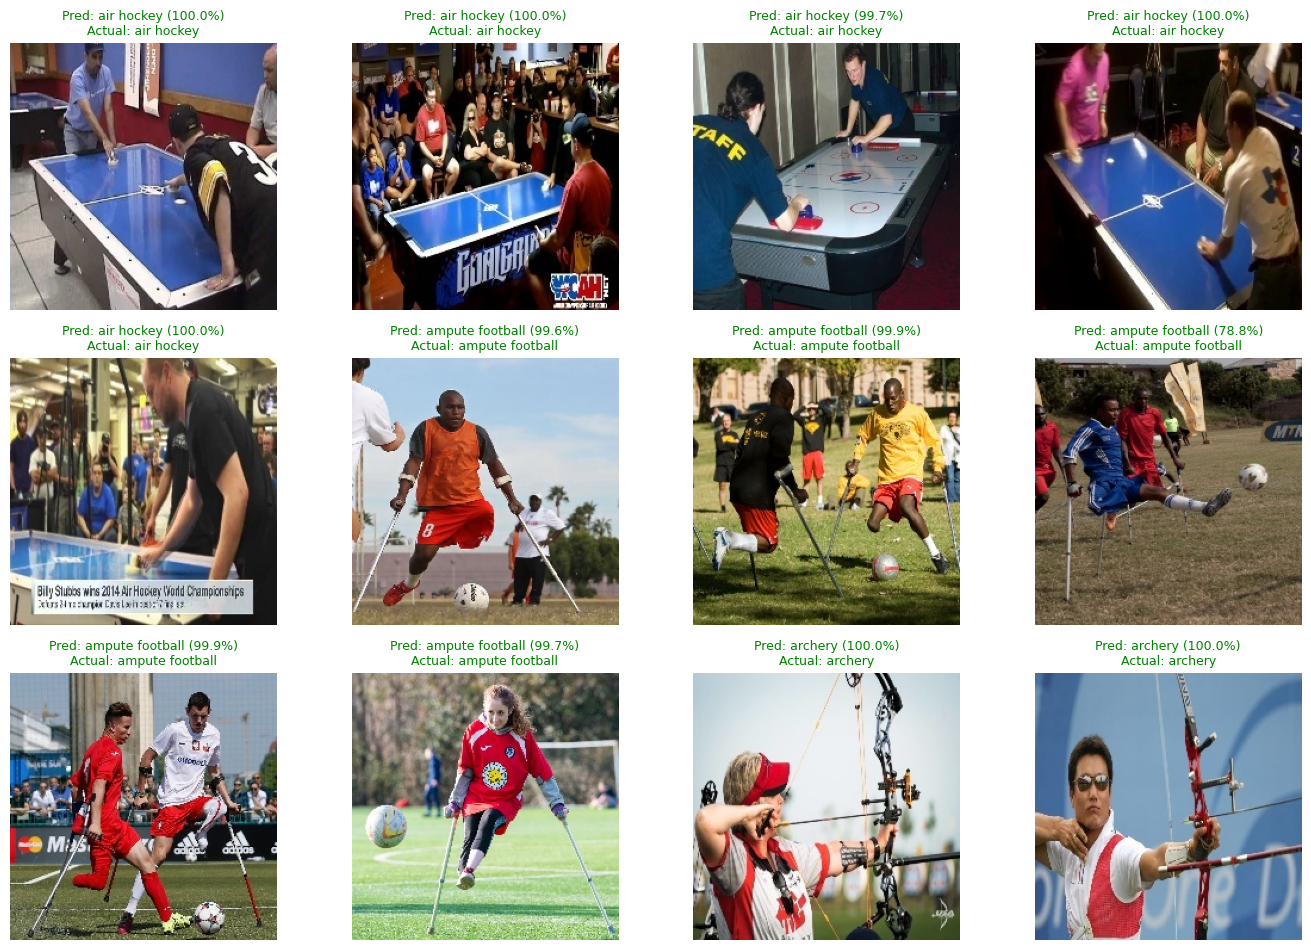

In [10]:
show = min(SHOW_IMAGES, len(preds))
cols = 4
rows_grid = math.ceil(show / cols)

plt.figure(figsize=(14, 3.2 * rows_grid))

for i, r in enumerate(preds[:show]):
    path = r.path
    img = cv2.imread(path)
    if img is None:
        print("Could not read:", path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    predicted = r.names[r.probs.top1]
    conf = float(r.probs.top1conf)
    actual = os.path.basename(os.path.dirname(path))
    ok = (predicted == actual)

    plt.subplot(rows_grid, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted} ({conf * 100:.1f}%)\nActual: {actual}",
              fontsize=9, color="green" if ok else "red")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 11. Saving the Results

In [ ]:
df.to_csv("sports_predictions.csv", index=False)
shutil.copy(BEST_MODEL, "best_sports_model.pt")

print("Saved: sports_predictions.csv")
print("Saved: best_sports_model.pt")

#results are saved in sports_predictions.csv

Saved: sports_predictions.csv
Saved: best_sports_model.pt
